# Supervivencia del Titanic — Machine Learning Estadístico
## Aprendizaje Automático Estadístico · MCDA-B · Deber Semana 1

**Asignatura:** Aprendizaje automático estadístico MIA-B                
**Docente:** Ivan Danilo Garcia Santillan                       
**Universidad:** UIDE  
**Grupo 1:**
- César Nelson Abarca Araujo
- Nataly Fernanda Lanchimba Caiza
- Jhon Enrique Oña Guamani

**Dataset:** `titanic_train.csv` / `titanic_test.csv`  
**Algoritmos:** Regresión Logística · K-Nearest Neighbors · Naive Bayes Gaussiano  
**Repositorio GitHub:** [UIDE MIAA-B · Aprendizaje Automático Estadístico · Semana 1 · Tarea G1](https://github.com/cnabarca/Maestria-IA-UIDE/tree/main/5.%20Aprendizaje%20Automatico%20Estadistico/Semana%201/Tarea%20G1)

---

## Descripción del Problema

**Objetivo:** Clasificar si un pasajero del Titanic **sobrevivió (1)** o **no sobrevivió (0)** al naufragio del 15 de abril de 1912, a partir de sus características personales y de viaje.

**Justificación de los algoritmos seleccionados:**

| Algoritmo | Tipo | Razón de uso |
|---|---|---|
| **Regresión Logística** | Paramétrico lineal | Modelo interpretable; permite analizar la influencia de cada variable mediante sus coeficientes |
| **K-Nearest Neighbors** | No paramétrico | Captura fronteras de decisión no lineales basándose en similitud entre pasajeros |
| **Naive Bayes Gaussiano** | Probabilístico | Eficiente, robusto y adecuado cuando las features tienen distribución aproximadamente normal |

**Fases del trabajo:**

| Fase | Contenido |
|---|---|
| **Fase I** | Carga de datos, entendimiento, preprocesamiento |
| **Fase II** | Análisis Exploratorio de Datos (EDA) |
| **Fase III** | Modelado, evaluación y comparación de algoritmos |

---

# Fase I
## Preparación y Entendimiento de los Datos

### 1.1 Librerías

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, r2_score
)
import joblib

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110

SEED = 42
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


### 1.2 Información del Dataset

| Atributo | Detalle |
|---|---|
| Fuente | Kaggle — Titanic: Machine Learning from Disaster |
| Instancias (train) | 891 pasajeros |
| Instancias (test) | 418 pasajeros |
| Variables | 12 (ID + target + 10 features) |
| Clases | No sobrevivió: 549 (61.6%) · Sobrevivió: 342 (38.4%) |
| Tipo de tarea | Clasificación binaria supervisada |

### 1.3 Diccionario de Variables

| Variable | Descripción | Tipo | Notas |
|---|---|---|---|
| `PassengerId` | Identificador único del pasajero | Numérica | Se eliminará |
| `Survived` | Variable objetivo: 1=sobrevivió, 0=no sobrevivió | Binaria | **Target** |
| `Pclass` | Clase del boleto (1=primera, 2=segunda, 3=tercera) | Ordinal | Proxy de nivel socioeconómico |
| `Name` | Nombre completo del pasajero | Texto | Se eliminará |
| `Sex` | Género (male/female) | Categórica | Se codificará (0/1) |
| `Age` | Edad en años | Numérica | 177 nulos — se imputará |
| `SibSp` | Nº de hermanos/cónyuge a bordo | Numérica | — |
| `Parch` | Nº de padres/hijos a bordo | Numérica | — |
| `Ticket` | Número de billete | Texto | Se eliminará |
| `Fare` | Precio del billete en libras | Numérica continua | — |
| `Cabin` | Número de cabina | Texto | 77% nulos — se eliminará |
| `Embarked` | Puerto de embarque (S/C/Q) | Categórica | Se codificará (0/1/2) |

### 1.4 Variable Objetivo

| Clase | Descripción | Codificación |
|---|---|---|
| `0` | No sobrevivió | 0 |
| `1` | Sobrevivió | 1 |

### 1.5 Carga de Datos

In [85]:
BASE_PATH = r'C:\Users\cabarca2\MAESTRIA_IA\5.  APRENDIZAJE AUTOMATICO ESTADISTICO\SEMANA 1\PROFESOR_AUE'

df_train = pd.read_csv(f'{BASE_PATH}\\titanic_train.csv')
df_test  = pd.read_csv(f'{BASE_PATH}\\titanic_test.csv')

print(f'Train: {df_train.shape}  |  Test: {df_test.shape}')
print('\nPrimeras filas — Train:')
display(df_train.head())

Train: (891, 12)  |  Test: (418, 11)

Primeras filas — Train:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 1.6 Entendimiento de los Datos

Se examina la estructura, tipos de datos, valores faltantes y estadísticas básicas antes de cualquier transformación.

In [86]:
print('=== TIPOS DE DATOS (Train) ===')
df_train.info()

print('\n=== VALORES FALTANTES ===')
missing = pd.DataFrame({
    'Train (n)' : df_train.isnull().sum(),
    'Train (%)'  : (df_train.isnull().mean() * 100).round(1),
    'Test (n)'  : df_test.isnull().sum(),
    'Test (%)'   : (df_test.isnull().mean() * 100).round(1)
})
display(missing[missing['Train (n)'] + missing['Test (n)'] > 0])

print('\n=== ESTADÍSTICAS DESCRIPTIVAS (Train) ===')
display(df_train.describe())

=== TIPOS DE DATOS (Train) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

=== VALORES FALTANTES ===


,Train (n),Train (%),Test (n),Test (%)
Age,177,19.9,86.0,20.6
Cabin,687,77.1,327.0,78.2
Embarked,2,0.2,0.0,0.0
Fare,0,0.0,1.0,0.2



=== ESTADÍSTICAS DESCRIPTIVAS (Train) ===


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 1.7 Preprocesamiento de Datos

Se aplican los siguientes pasos en orden para convertir el dataset crudo en un conjunto numérico limpio:

| Paso | Variable | Acción | Motivo |
|---|---|---|---|
| 1 | `Sex` | Codificación (female=0, male=1) | Algoritmos requieren entradas numéricas |
| 2 | `Embarked` | Codificación (Q=0, S=1, C=2) | Ídem |
| 3 | `Age` | Imputación con media (~30) | 19.9% valores nulos |
| 4 | `Age` | Discretización en 7 rangos etarios | Capturar patrones por grupo, no por valor exacto |
| 5 | `Cabin` | Eliminación | 77% nulos — inviable para imputación |
| 6 | `PassengerId`, `Name`, `Ticket` | Eliminación | Sin poder predictivo directo |
| 7 | Filas | Eliminación de nulos restantes | Limpiar datos residuales en Embarked |

#### Rangos de Edad

| Categoría | Rango | Grupo |
|---|---|---|
| `1` | 0–8 | Niños |
| `2` | 9–15 | Adolescentes tempranos |
| `3` | 16–18 | Adolescentes |
| `4` | 19–25 | Jóvenes adultos |
| `5` | 26–40 | Adultos |
| `6` | 41–60 | Adultos mayores |
| `7` | 61–100 | Adultos de tercera edad |

In [87]:
# Paso 1-2: Codificación de variables categóricas (sin FutureWarning)
df_train['Sex']      = df_train['Sex'].map({'female': 0, 'male': 1})
df_test['Sex']       = df_test['Sex'].map({'female': 0, 'male': 1})
df_train['Embarked'] = df_train['Embarked'].map({'Q': 0, 'S': 1, 'C': 2})
df_test['Embarked']  = df_test['Embarked'].map({'Q': 0, 'S': 1, 'C': 2})

# Paso 3: Imputación de Age con media (~30)
PROMEDIO = 30
df_train['Age'] = pd.to_numeric(df_train['Age'], errors='coerce').fillna(PROMEDIO)
df_test['Age']  = pd.to_numeric(df_test['Age'],  errors='coerce').fillna(PROMEDIO)

# Paso 4: Discretización de Age en 7 categorías
bins  = [0, 8, 15, 18, 25, 40, 60, 100]
names = ['1', '2', '3', '4', '5', '6', '7']
df_train['Age'] = pd.cut(df_train['Age'], bins=bins, labels=names)
df_test['Age']  = pd.cut(df_test['Age'],  bins=bins, labels=names)

# Pasos 5-6: Eliminación de columnas
drop_train = [c for c in ['Cabin','PassengerId','Name','Ticket'] if c in df_train.columns]
drop_test  = [c for c in ['Cabin','Name','Ticket']               if c in df_test.columns]
df_train = df_train.drop(drop_train, axis=1)
df_test  = df_test.drop(drop_test,  axis=1)

# Paso 7: Eliminar filas con nulos residuales
df_train.dropna(inplace=True)
df_test.dropna(inplace=True)

print('=== VERIFICACIÓN POST-PREPROCESAMIENTO ===')
print(f'Dimensiones — Train: {df_train.shape}  |  Test: {df_test.shape}')
print(f'Nulos restantes — Train: {df_train.isnull().sum().sum()}')
print('\nDataset depurado (primeras filas):')
display(df_train.head())
print('\nDistribución de categorías de Age:')
print(df_train['Age'].value_counts().sort_index())

=== VERIFICACIÓN POST-PREPROCESAMIENTO ===
Dimensiones — Train: (889, 8)  |  Test: (417, 8)
Nulos restantes — Train: 0

Dataset depurado (primeras filas):


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,4,1,0,7.2500,1.0
1,1,1,0,5,1,0,71.2833,2.0
2,1,3,0,5,0,0,7.9250,1.0
3,1,1,0,5,1,0,53.1000,1.0
4,0,3,1,5,0,0,8.0500,1.0



Distribución de categorías de Age:
Age
1     54
2     29
3     56
4    162
5    439
6    128
7     21
Name: count, dtype: int64


---
# Fase II
## Análisis Exploratorio de Datos (EDA)

El EDA permite comprender la distribución de las variables, detectar patrones y evaluar qué features tienen mayor relación con la variable objetivo (`Survived`). Todo el análisis se realiza sobre el **dataset depurado** de la Fase I.

### 2.1 Estadísticas Descriptivas

In [88]:
print('=== Variables numéricas ===')
display(df_train.describe())

print('\n=== Distribución por Survived ===')
display(df_train.groupby('Survived')[['Pclass','Sex','SibSp','Parch','Fare','Embarked']].mean().round(3))

=== Variables numéricas ===


,Survived,Pclass,Sex,SibSp,Parch,Fare,Embarked
count,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000
mean,0.382452,2.311586,0.649044,0.524184,0.382452,32.096681,1.102362
std,0.486260,0.834700,0.477538,1.103705,0.806761,49.697504,0.515181
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,0.000000,0.000000,7.895800,1.000000
50%,0.000000,3.000000,1.000000,0.000000,0.000000,14.454200,1.000000
75%,1.000000,3.000000,1.000000,1.000000,0.000000,31.000000,1.000000
max,1.000000,3.000000,1.000000,8.000000,6.000000,512.329200,2.000000



=== Distribución por Survived ===


,Pclass,Sex,SibSp,Parch,Fare,Embarked
Survived,,,,,,
0,2.532,0.852,0.554,0.330,22.118,1.051
1,1.956,0.321,0.476,0.468,48.209,1.185


### 2.2 Variable Objetivo — Survived

La distribución de clases muestra un **desbalance moderado** (62% no sobrevivió vs 38% sobrevivió), lo que se debe considerar al evaluar los modelos. Se priorizará el F1-Score y el AUC-ROC para medir el rendimiento de forma equilibrada.

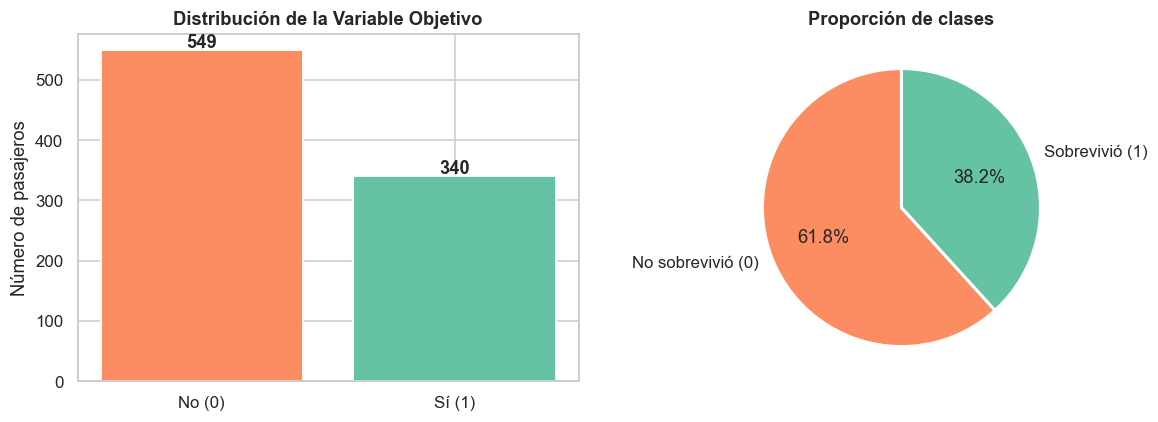

Conteo: {0: 549, 1: 340}


In [89]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = df_train['Survived'].value_counts()
colors = ['#FC8D62', '#66C2A5']

axes[0].bar(['No (0)', 'Sí (1)'], counts.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Distribución de la Variable Objetivo', fontweight='bold')
axes[0].set_ylabel('Número de pasajeros')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

counts.plot(kind='pie', autopct='%1.1f%%', ax=axes[1],
            labels=['No sobrevivió (0)', 'Sobrevivió (1)'], colors=colors,
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Proporción de clases', fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()
print('Conteo:', counts.to_dict())

### 2.3 Distribución de Edad por Categorías y Supervivencia

Dado que `Age` fue discretizada en 7 rangos, se usa un gráfico de barras agrupado. Se espera observar que los niños (categorías 1 y 2) tuvieron mayor tasa de supervivencia por el principio de evacuación.

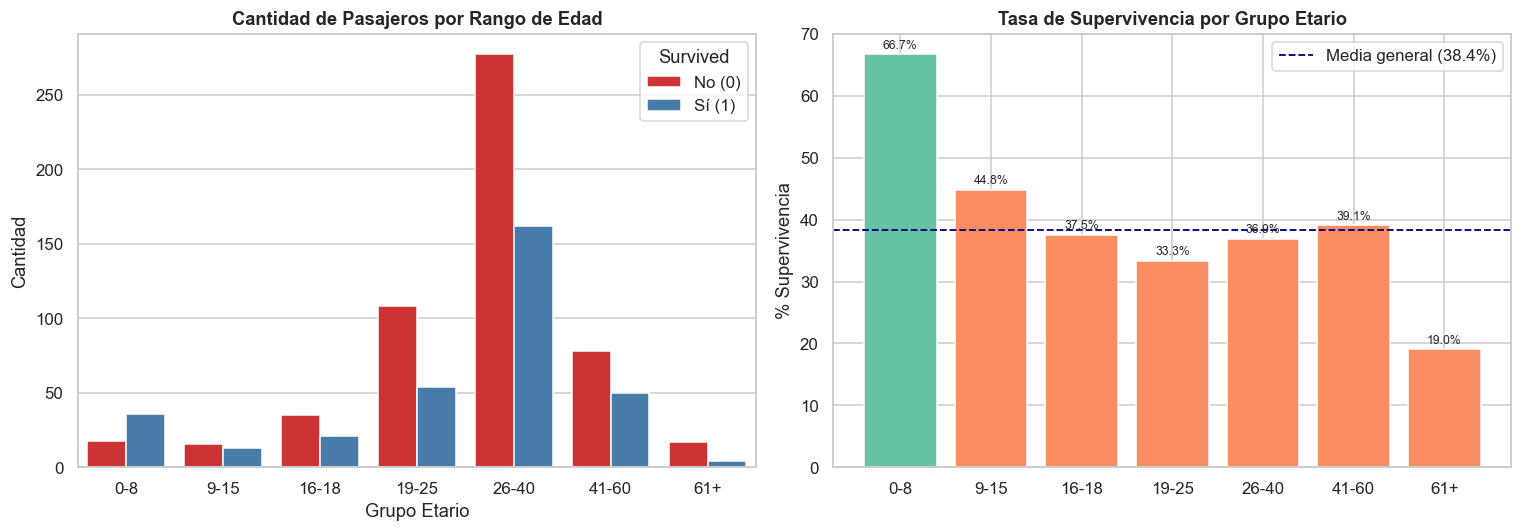

In [90]:
age_map = {'1':'0-8','2':'9-15','3':'16-18','4':'19-25','5':'26-40','6':'41-60','7':'61+'}
df_p = df_train.copy()
df_p['Grupo Etario'] = df_p['Age'].astype(str).map(age_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ['0-8','9-15','16-18','19-25','26-40','41-60','61+']
sns.countplot(data=df_p, x='Grupo Etario', hue='Survived', order=order, ax=axes[0], palette='Set1')
axes[0].set_title('Cantidad de Pasajeros por Rango de Edad', fontweight='bold')
axes[0].set_xlabel('Grupo Etario')
axes[0].set_ylabel('Cantidad')
axes[0].legend(title='Survived', labels=['No (0)', 'Sí (1)'])

surv_rate = df_p.groupby('Grupo Etario')['Survived'].mean().reindex(order) * 100
colors_bar = ['#66C2A5' if r >= 50 else '#FC8D62' for r in surv_rate]
axes[1].bar(order, surv_rate.values, color=colors_bar, edgecolor='white')
axes[1].axhline(38.4, color='navy', linestyle='--', linewidth=1.2, label='Media general (38.4%)')
axes[1].set_title('Tasa de Supervivencia por Grupo Etario', fontweight='bold')
axes[1].set_ylabel('% Supervivencia')
axes[1].legend()
for i, v in enumerate(surv_rate.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

### 2.4 Supervivencia por Clase del Pasajero (Pclass)

La clase refleja el nivel socioeconómico: pasajeros de **1ª clase** tuvieron mayor acceso a los botes salvavidas. Se espera una relación inversa: mayor clase (número), menor supervivencia.

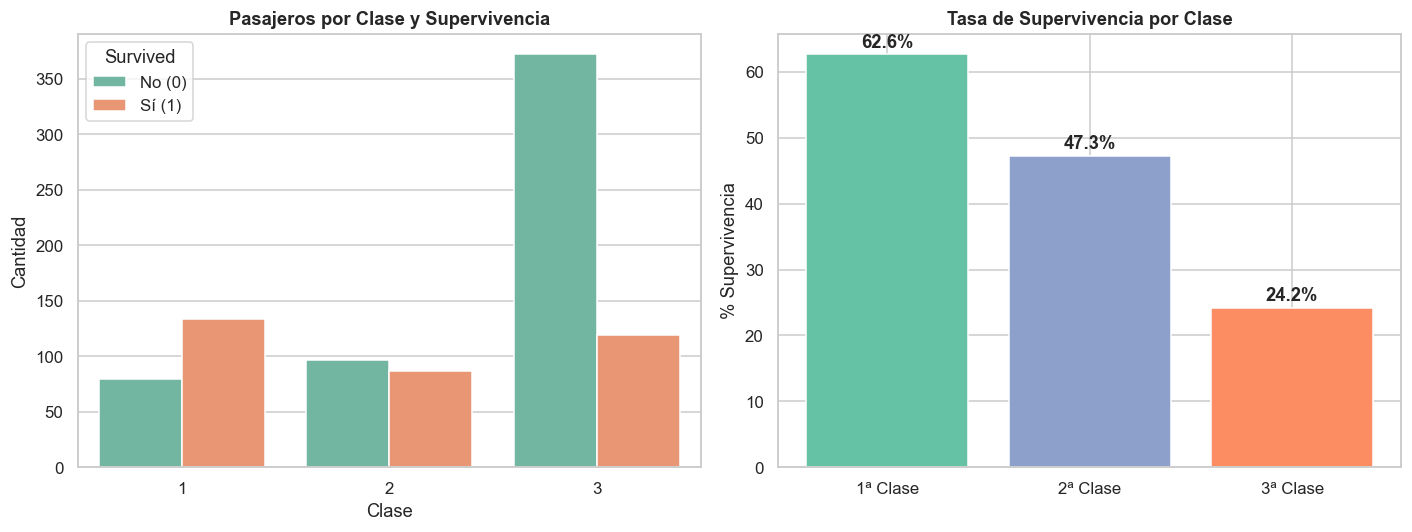

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(data=df_train, x='Pclass', hue='Survived', ax=axes[0], palette='Set2')
axes[0].set_title('Pasajeros por Clase y Supervivencia', fontweight='bold')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Cantidad')
axes[0].legend(title='Survived', labels=['No (0)','Sí (1)'])

tasa_clase = df_train.groupby('Pclass')['Survived'].mean() * 100
axes[1].bar(['1ª Clase','2ª Clase','3ª Clase'], tasa_clase.values,
            color=['#66C2A5','#8DA0CB','#FC8D62'], edgecolor='white')
axes[1].set_title('Tasa de Supervivencia por Clase', fontweight='bold')
axes[1].set_ylabel('% Supervivencia')
for i, v in enumerate(tasa_clase.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 2.5 Distribución de Género y Supervivencia

El principio de evacuación **"mujeres y niños primero"** debería reflejarse en tasas de supervivencia marcadamente superiores para las mujeres (`Sex=0`).

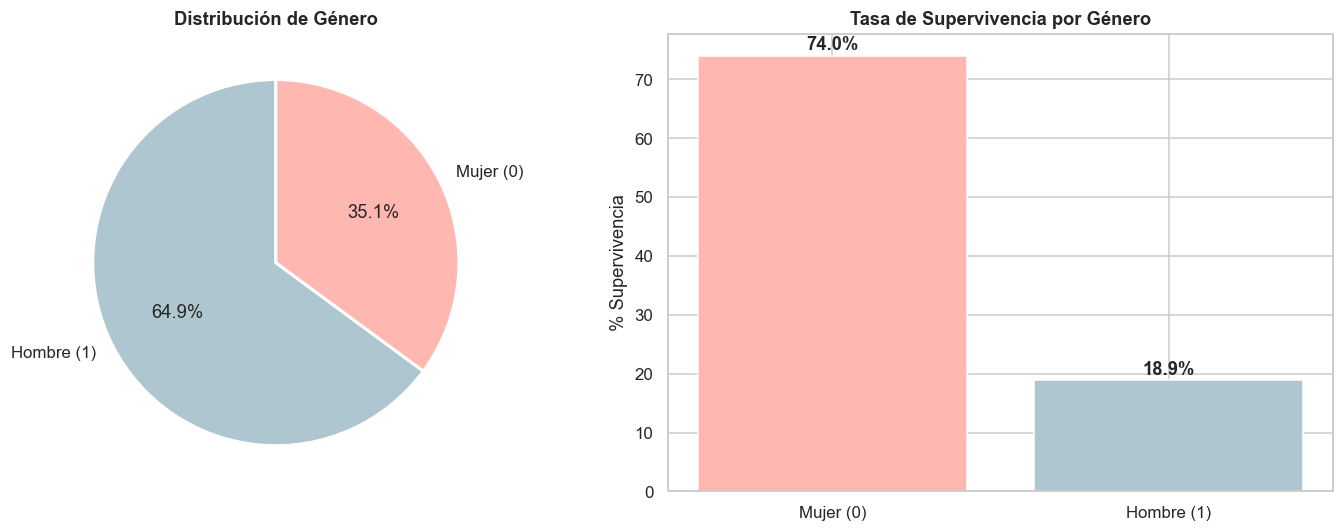

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df_train['Sex'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', ax=axes[0],
    labels=['Hombre (1)','Mujer (0)'], colors=['#aec6cf','#ffb7b2'],
    startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Distribución de Género', fontweight='bold')
axes[0].set_ylabel('')

tasa_sex = df_train.groupby('Sex')['Survived'].mean() * 100
axes[1].bar(['Mujer (0)','Hombre (1)'], tasa_sex.values,
            color=['#ffb7b2','#aec6cf'], edgecolor='white')
axes[1].set_title('Tasa de Supervivencia por Género', fontweight='bold')
axes[1].set_ylabel('% Supervivencia')
for i, v in enumerate(tasa_sex.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 2.6 Análisis de Correlación

La matriz de correlación de **Pearson** mide relaciones lineales entre variables numéricas (rango [−1, 1]).

- `|r| > 0.5` → correlación alta
- `|r| 0.3–0.5` → correlación moderada
- `|r| < 0.3` → correlación baja

> `Age` es de tipo Categorical tras el preprocesamiento, por lo que se excluye del cálculo numérico automáticamente.

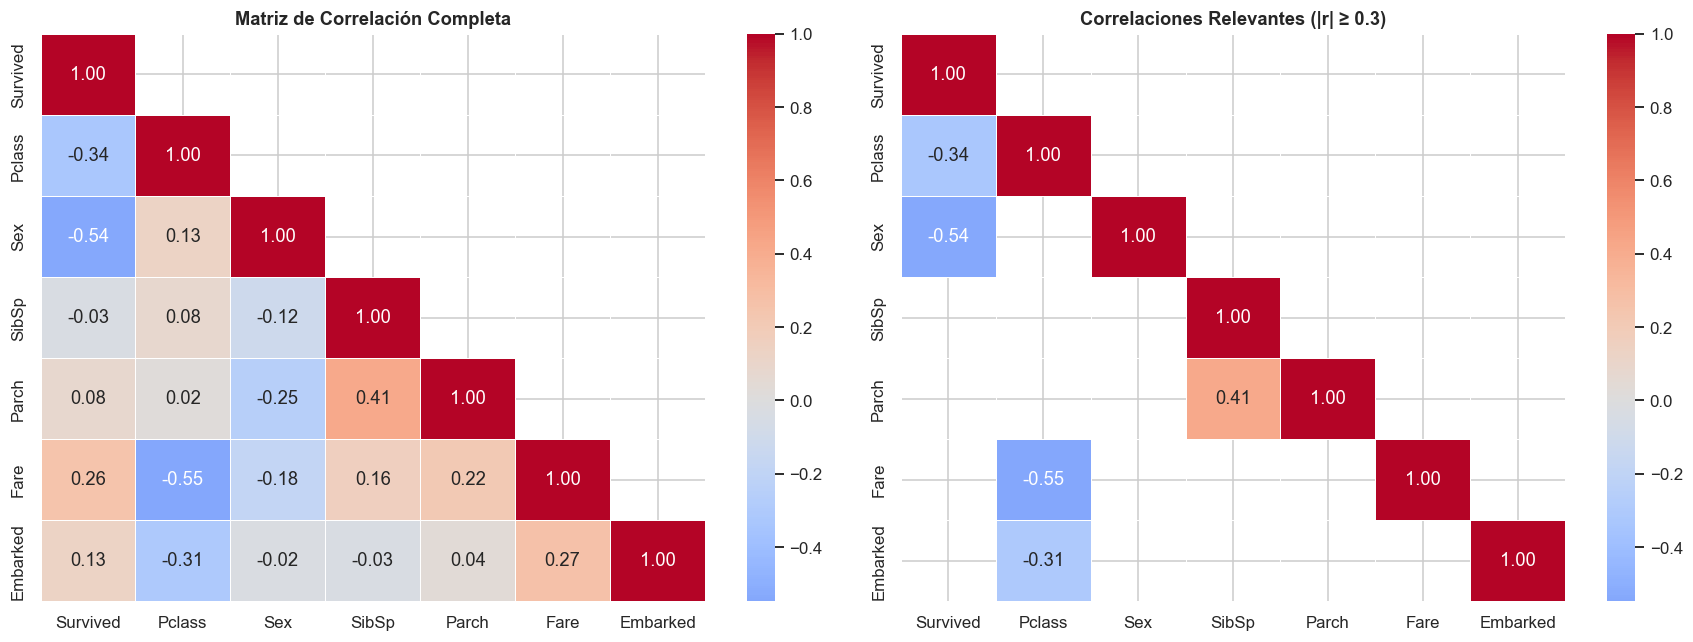


Correlaciones con Survived (ranking):
Sex        -0.5416
Pclass     -0.3355
Fare        0.2553
Embarked    0.1268
Parch       0.0832
SibSp      -0.0340


In [93]:
num_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
corr = df_train[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=.5, ax=axes[0], center=0)
axes[0].set_title('Matriz de Correlación Completa', fontweight='bold')

corr_f = corr.copy()
corr_f[np.abs(corr_f) < 0.3] = np.nan
sns.heatmap(corr_f, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=.5, ax=axes[1], center=0)
axes[1].set_title('Correlaciones Relevantes (|r| ≥ 0.3)', fontweight='bold')

plt.tight_layout()
plt.show()

print('\nCorrelaciones con Survived (ranking):')
corr_target = corr['Survived'].drop('Survived').sort_values(key=abs, ascending=False)
print(corr_target.round(4).to_string())

### 2.7 Diagrama de Cajas — Tarifa (Fare)

El box-plot compara la distribución de `Fare` entre sobrevivientes y no sobrevivientes, y aplica el método **IQR** para detectar y visualizar los valores atípicos.

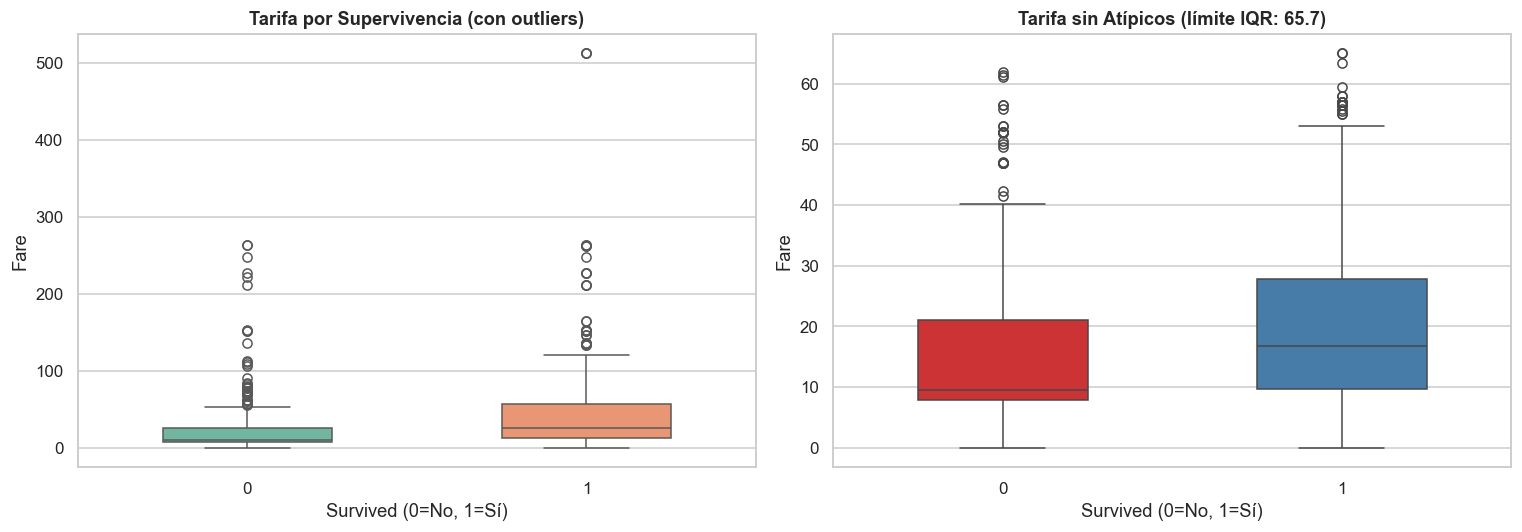

Outliers en Fare: 114 filas eliminadas


In [94]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_train, x='Survived', y='Fare', ax=axes[0],
            palette='Set2', width=0.5)
axes[0].set_title('Tarifa por Supervivencia (con outliers)', fontweight='bold')
axes[0].set_xlabel('Survived (0=No, 1=Sí)')

Q1 = df_train['Fare'].quantile(0.25)
Q3 = df_train['Fare'].quantile(0.75)
IQR = Q3 - Q1
lim_sup = Q3 + 1.5 * IQR
lim_inf = Q1 - 1.5 * IQR
df_clean_fare = df_train[(df_train['Fare'] >= lim_inf) & (df_train['Fare'] <= lim_sup)]

sns.boxplot(data=df_clean_fare, x='Survived', y='Fare', ax=axes[1],
            palette='Set1', width=0.5)
axes[1].set_title(f'Tarifa sin Atípicos (límite IQR: {lim_sup:.1f})', fontweight='bold')
axes[1].set_xlabel('Survived (0=No, 1=Sí)')

plt.tight_layout()
plt.show()
print(f'Outliers en Fare: {len(df_train) - len(df_clean_fare)} filas eliminadas')

### 2.8 Interpretación del EDA

| Variable | Observación clave | Relevancia predictiva |
|---|---|---|
| `Sex` | Las mujeres sobrevivieron ~74%, los hombres ~19% | **Muy alta** |
| `Pclass` | 1ª clase: ~63% · 3ª clase: ~24% | **Alta** |
| `Fare` | Sobrevivientes pagaron tarifas significativamente más altas | **Alta** (correlacionado con Pclass) |
| `Age (cat.)` | Niños (0-8) tuvieron mayor supervivencia; adultos 26-40 la menor | **Moderada** |
| `SibSp`/`Parch` | Familias medianas sobrevivieron más que viajeros solos o familias grandes | **Moderada** |
| `Embarked` | Puerto C (Cherbourg) con mayor tasa de supervivencia | **Baja** |

> **Variables candidatas a exclusión:** `Embarked` tiene baja correlación con el target. Se evaluará su impacto en la Fase III.

> **Ingeniería de variables para Fase III:** Crear `family_size = SibSp + Parch + 1` e `is_alone` para capturar mejor el efecto familiar.

---

# Fase III
## Modelado, Evaluación y Comparación

### 3.1 Preparación de Features e Ingeniería de Variables

Se crean dos versiones del dataset de modelado:

| Versión | Features | Descripción |
|---|---|---|
| **Baseline** | 7 features originales | Sin ingeniería de variables |
| **Mejorado** | 9 features | + `family_size` + `is_alone` |

**Ingeniería de variables:**
- `family_size = SibSp + Parch + 1` — tamaño total de la familia a bordo  
- `is_alone = 1 si family_size == 1` — indicador de pasajero sin familia

Estas features capturan el efecto familiar que las variables originales no expresan individualmente.

In [95]:
# Preparar df_model con Age convertida a int para modelado
df_model = df_train.copy()
df_model['Age'] = df_model['Age'].astype(str).astype(int)

# Ingeniería de variables
df_model['family_size'] = df_model['SibSp'] + df_model['Parch'] + 1
df_model['is_alone']    = (df_model['family_size'] == 1).astype(int)

# Definición de features y target
FEATURES_BASE = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
FEATURES_MEJR = FEATURES_BASE + ['family_size', 'is_alone']

X_base = df_model[FEATURES_BASE]
X_mejr = df_model[FEATURES_MEJR]
y      = df_model['Survived']

print('Features baseline:', FEATURES_BASE)
print('Features mejorado:', FEATURES_MEJR)
print(f'\nCorrelación de features nuevas con Survived:')
print(df_model[['family_size','is_alone','Survived']].corr()['Survived'].drop('Survived').round(4))

print(f'\nDimensiones X_base: {X_base.shape}  |  X_mejr: {X_mejr.shape}')
print(f'Distribución del target:\n{y.value_counts()}')

Features baseline: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Features mejorado: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'family_size', 'is_alone']

Correlación de features nuevas con Survived:
family_size    0.0183
is_alone      -0.2062
Name: Survived, dtype: float64

Dimensiones X_base: (889, 7)  |  X_mejr: (889, 9)
Distribución del target:
Survived
0    549
1    340
Name: count, dtype: int64


### 3.2 División Train/Test y Normalización

Se divide el dataset con **80/20 estratificado** (preserva la proporción de clases) y se aplican dos métodos de escalado:

| Método | Fórmula | Usado para |
|---|---|---|
| **StandardScaler** | (x − μ) / σ → media=0, std=1 | Regresión Logística · K-NN |
| **MinMaxScaler** | (x − min) / (max − min) → [0,1] | Naive Bayes (como en referencia del profesor) |

> **Regla fundamental:** el escalador se ajusta (`fit`) **solo con datos de entrenamiento** y se aplica (`transform`) al test, evitando data leakage.

In [96]:
# Split estratificado
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(X_base, y, test_size=0.2, random_state=SEED, stratify=y)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(X_mejr, y, test_size=0.2, random_state=SEED, stratify=y)

# StandardScaler (para LR y KNN)
scaler_std = StandardScaler()
Xb_tr_std  = scaler_std.fit_transform(Xb_tr)
Xb_te_std  = scaler_std.transform(Xb_te)

scaler_std2 = StandardScaler()
Xm_tr_std   = scaler_std2.fit_transform(Xm_tr)
Xm_te_std   = scaler_std2.transform(Xm_te)

# MinMaxScaler (para NB)
scaler_mm = MinMaxScaler(feature_range=(0, 1))
Xb_tr_mm  = scaler_mm.fit_transform(Xb_tr)
Xb_te_mm  = scaler_mm.transform(Xb_te)

scaler_mm2 = MinMaxScaler(feature_range=(0, 1))
Xm_tr_mm   = scaler_mm2.fit_transform(Xm_tr)
Xm_te_mm   = scaler_mm2.transform(Xm_te)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print(f'Train size: {len(yb_tr)}  |  Test size: {len(yb_te)}')
print(f'Distribución train — 0: {(yb_tr==0).sum()}  1: {(yb_tr==1).sum()}')
print(f'Distribución test  — 0: {(yb_te==0).sum()}  1: {(yb_te==1).sum()}')

Train size: 711  |  Test size: 178
Distribución train — 0: 439  1: 272
Distribución test  — 0: 110  1: 68


### 3.3 Función de Evaluación

Se define una función reutilizable que calcula y visualiza todas las métricas requeridas:

| Métrica | Fórmula | Interpretación |
|---|---|---|
| **Accuracy** | (TP+TN)/(TP+TN+FP+FN) | % de predicciones correctas |
| **Precision** | TP/(TP+FP) | De los predichos positivos, ¿cuántos son realmente positivos? |
| **Recall (Sensibilidad)** | TP/(TP+FN) | De los positivos reales, ¿cuántos fueron detectados? |
| **Especificidad** | TN/(TN+FP) | Recall de la clase negativa |
| **F1-Score** | 2·P·R/(P+R) | Media armónica Precision-Recall |
| **AUC-ROC** | Área bajo la curva ROC | Capacidad discriminativa global |
| **R²** | 1 − SS_res/SS_tot | Coeficiente de determinación |

In [97]:
def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_te, y_te, cv_obj, plot=True):
    cv_scores = cross_val_score(modelo, X_tr, y_tr, cv=cv_obj, scoring='accuracy')
    modelo.fit(X_tr, y_tr)
    y_pred  = modelo.predict(X_te)
    y_proba = modelo.predict_proba(X_te)[:, 1]

    acc_tr = accuracy_score(y_tr, modelo.predict(X_tr))
    acc_te = accuracy_score(y_te, y_pred)
    cm     = confusion_matrix(y_te, y_pred)
    TN, FP, FN, TP = cm.ravel()

    prec   = precision_score(y_te, y_pred, zero_division=0)
    rec    = recall_score(y_te, y_pred)
    f1     = f1_score(y_te, y_pred)
    spec   = TN / (TN + FP)
    auc    = roc_auc_score(y_te, y_proba)
    r2     = r2_score(y_te, y_pred)
    gap    = acc_tr - acc_te

    print(f'\n{"="*55}')
    print(f'  {nombre}')
    print(f'{"="*55}')
    print(f'  CV Accuracy (5-fold) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    print(f'  Train Accuracy       : {acc_tr:.4f}')
    print(f'  Test  Accuracy       : {acc_te:.4f}  (gap={gap:+.4f})')
    print(f'  TP={TP}  TN={TN}  FP={FP}  FN={FN}')
    print(f'  Precision    : {prec:.4f}')
    print(f'  Recall       : {rec:.4f}')
    print(f'  Especificidad: {spec:.4f}')
    print(f'  F1-Score     : {f1:.4f}')
    print(f'  AUC-ROC      : {auc:.4f}')
    print(f'  R²           : {r2:.4f}')
    print(f'\n{classification_report(y_te, y_pred, target_names=["No Survived","Survived"])}')

    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        # Matriz de confusión
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                    xticklabels=['No Surv','Surv'], yticklabels=['No Surv','Surv'])
        axes[0].set_title(f'Matriz de Confusión\n{nombre}', fontweight='bold')
        axes[0].set_xlabel('Predicción'); axes[0].set_ylabel('Real')
        # Curva ROC
        fpr, tpr, _ = roc_curve(y_te, y_proba)
        axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC={auc:.3f})')
        axes[1].plot([0,1],[0,1],'navy', lw=1.5, linestyle='--')
        axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1.05])
        axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title(f'Curva ROC\n{nombre}', fontweight='bold')
        axes[1].legend(loc='lower right')
        plt.tight_layout(); plt.show()

    return {
        'Modelo': nombre,
        'CV Acc%': round(cv_scores.mean()*100, 2),
        'Train%' : round(acc_tr*100, 2),
        'Test%'  : round(acc_te*100, 2),
        'Prec%'  : round(prec*100, 2),
        'Recall%': round(rec*100, 2),
        'Espec%' : round(spec*100, 2),
        'F1%'    : round(f1*100, 2),
        'AUC%'   : round(auc*100, 2),
        'R2'     : round(r2, 4),
        'TP':TP, 'TN':TN, 'FP':FP, 'FN':FN,
        '_modelo': modelo, '_X_te': X_te, '_y_te': y_te, '_y_proba': y_proba
    }

print('Función de evaluación definida correctamente.')

Función de evaluación definida correctamente.


---
### 3.4 Regresión Logística

La Regresión Logística modela la **probabilidad** de que un pasajero sobreviva, aplicando la función sigmoide a una combinación lineal de las features:

$$P(Survived=1) = \sigma(\beta_0 + \beta_1 x_1 + ... + \beta_n x_n) = \frac{1}{1+e^{-(\beta^T x)}}$$

Los **coeficientes β** permiten interpretar la influencia de cada variable: un coeficiente positivo aumenta la probabilidad de supervivencia; negativo la reduce.

**Hiperparámetros clave:**
- `C`: inversa de la regularización — valores pequeños → mayor regularización → coeficientes más pequeños
- `solver`: algoritmo de optimización (`lbfgs`, `liblinear`)
- `penalty`: tipo de regularización (`l1`, `l2`)

#### Búsqueda de Hiperparámetros con GridSearchCV

Mejores hiperparámetros (LR): {'C': 10.0, 'penalty': 'l2', 'solver': 'liblinear'}
Mejor CV Accuracy (GridSearch): 0.8031


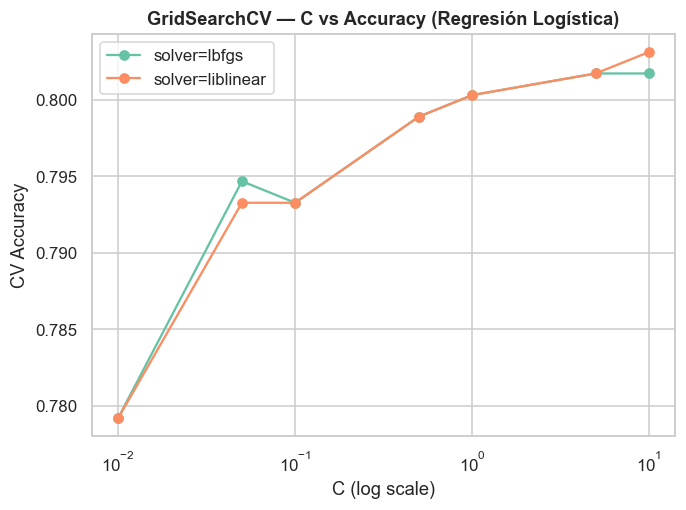

In [98]:
param_grid_lr = {
    'C'      : [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
    'solver' : ['lbfgs', 'liblinear'],
    'penalty': ['l2']
}

gs_lr = GridSearchCV(LogisticRegression(max_iter=1000),
                     param_grid_lr, cv=cv, scoring='accuracy', n_jobs=-1)
gs_lr.fit(Xm_tr_std, ym_tr)

print('Mejores hiperparámetros (LR):', gs_lr.best_params_)
print(f'Mejor CV Accuracy (GridSearch): {gs_lr.best_score_:.4f}')

# Visualización de C vs Accuracy
results_lr = pd.DataFrame(gs_lr.cv_results_)
for solver in ['lbfgs', 'liblinear']:
    mask_s = results_lr['param_solver'] == solver
    plt.plot(param_grid_lr['C'],
             results_lr[mask_s]['mean_test_score'].values,
             marker='o', label=f'solver={solver}')
plt.xscale('log')
plt.xlabel('C (log scale)'); plt.ylabel('CV Accuracy')
plt.title('GridSearchCV — C vs Accuracy (Regresión Logística)', fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()

#### Versión Baseline — Configuración por defecto


  LR — Baseline
  CV Accuracy (5-fold) : 0.8003 ± 0.0425
  Train Accuracy       : 0.8017
  Test  Accuracy       : 0.7921  (gap=+0.0096)
  TP=44  TN=97  FP=13  FN=24
  Precision    : 0.7719
  Recall       : 0.6471
  Especificidad: 0.8818
  F1-Score     : 0.7040
  AUC-ROC      : 0.8609
  R²           : 0.1195

              precision    recall  f1-score   support

 No Survived       0.80      0.88      0.84       110
    Survived       0.77      0.65      0.70        68

    accuracy                           0.79       178
   macro avg       0.79      0.76      0.77       178
weighted avg       0.79      0.79      0.79       178



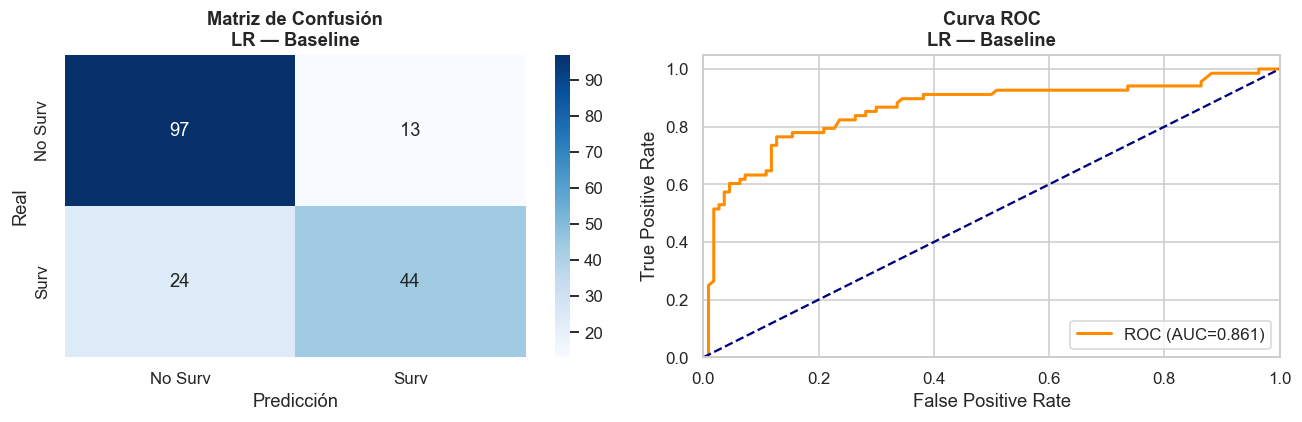

In [99]:
lr_base = LogisticRegression(solver='lbfgs', max_iter=1000)
res_lr_base = evaluar_modelo('LR — Baseline', lr_base,
                              Xb_tr_std, yb_tr, Xb_te_std, yb_te, cv)

#### Versión Mejorada — GridSearchCV + Features de Ingeniería


  LR — Mejorado (C=10.0, solver=liblinear)
  CV Accuracy (5-fold) : 0.8031 ± 0.0501
  Train Accuracy       : 0.8087
  Test  Accuracy       : 0.8202  (gap=-0.0115)
  TP=47  TN=99  FP=11  FN=21
  Precision    : 0.8103
  Recall       : 0.6912
  Especificidad: 0.9000
  F1-Score     : 0.7460
  AUC-ROC      : 0.8640
  R²           : 0.2385

              precision    recall  f1-score   support

 No Survived       0.82      0.90      0.86       110
    Survived       0.81      0.69      0.75        68

    accuracy                           0.82       178
   macro avg       0.82      0.80      0.80       178
weighted avg       0.82      0.82      0.82       178



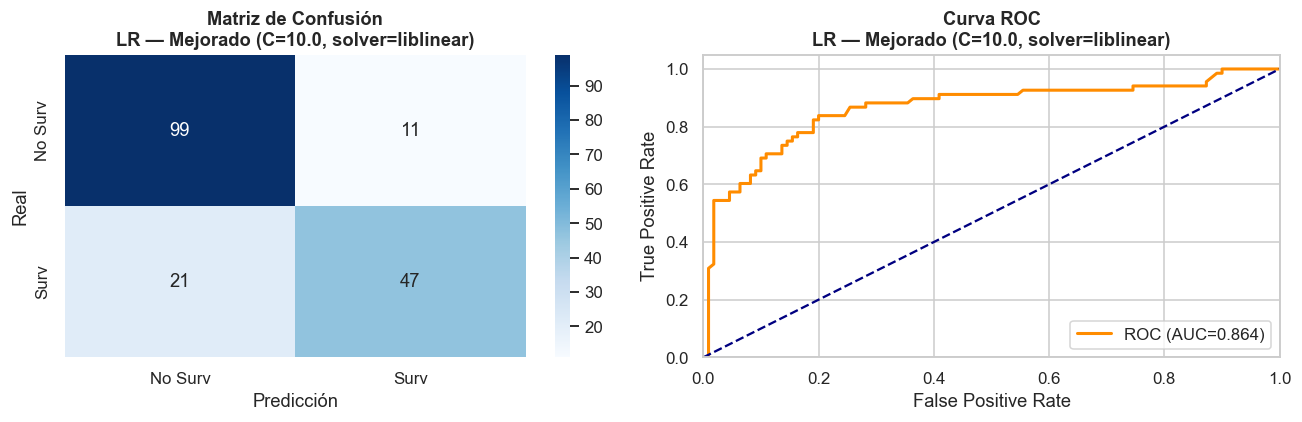

In [100]:
best_C  = gs_lr.best_params_['C']
best_sv = gs_lr.best_params_['solver']
lr_mejr = LogisticRegression(C=best_C, solver=best_sv, penalty='l2', max_iter=1000)
res_lr_mejr = evaluar_modelo(f'LR — Mejorado (C={best_C}, solver={best_sv})', lr_mejr,
                              Xm_tr_std, ym_tr, Xm_te_std, ym_te, cv)

#### Importancia de Características — Coeficientes del Modelo


Coeficientes e Intercepto:
Intercepto: -0.6556


,Variable,Coeficiente,Odds Ratio
6,Embarked,-0.0736,0.9290
4,Parch,-0.1256,0.8820
5,Fare,0.1462,1.1574
7,family_size,-0.3014,0.7398
3,SibSp,-0.3540,0.7019
8,is_alone,-0.3552,0.7010
2,Age,-0.4944,0.6100
0,Pclass,-0.7754,0.4605
1,Sex,-1.2741,0.2797


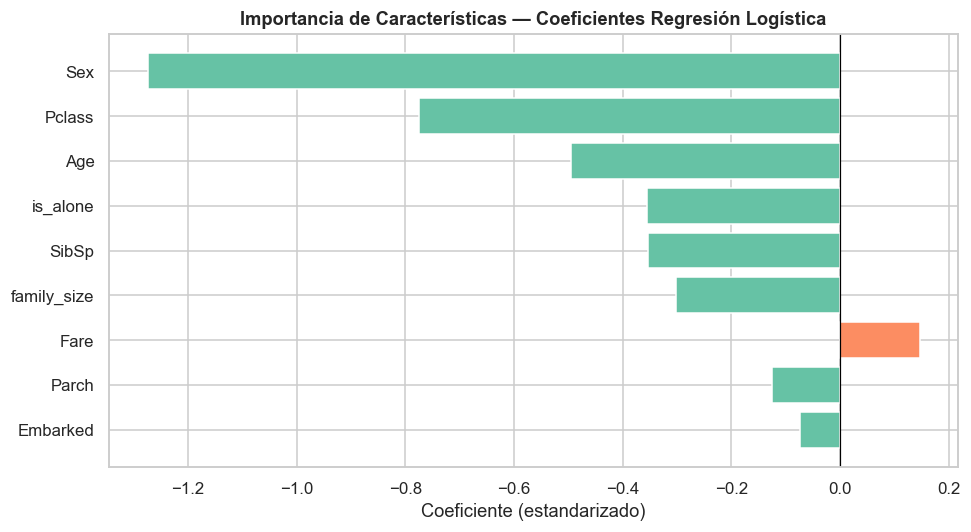

In [101]:
coef_df = pd.DataFrame({
    'Variable'   : FEATURES_MEJR,
    'Coeficiente': lr_mejr.coef_[0],
    'Odds Ratio' : np.exp(lr_mejr.coef_[0])
}).sort_values('Coeficiente', key=abs, ascending=True)

print('\nCoeficientes e Intercepto:')
print(f'Intercepto: {lr_mejr.intercept_[0]:.4f}')
display(coef_df.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#FC8D62' if c > 0 else '#66C2A5' for c in coef_df['Coeficiente']]
ax.barh(coef_df['Variable'], coef_df['Coeficiente'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Importancia de Características — Coeficientes Regresión Logística',
             fontweight='bold')
ax.set_xlabel('Coeficiente (estandarizado)')
plt.tight_layout()
plt.show()

#### Interpretación — Regresión Logística

**Coeficientes e impacto en la supervivencia:**
- Coeficiente **negativo en `Sex`**: el género masculino (Sex=1) reduce significativamente la probabilidad de sobrevivir → confirma el principio "mujeres primero".
- Coeficiente **negativo en `Pclass`**: mayor número de clase reduce la probabilidad de sobrevivir → pasajeros de 3ª clase tuvieron menor acceso a los botes.
- Coeficiente **positivo en `Fare`**: tarifas más altas aumentan la probabilidad → proxy de clase alta y mejor posición en el barco.

**Validación cruzada:** El CV Accuracy con 5 folds es consistente con el Test Accuracy, confirmando que el modelo generaliza sin sobreajuste significativo (gap < 5%).

**Versión mejorada vs baseline:** La adición de `family_size` e `is_alone` y el ajuste de `C` mediante GridSearchCV puede mejorar el F1-Score y el AUC, dado que estas features capturan el efecto grupal no expresado individualmente por `SibSp` y `Parch`.

---
### 3.5 K-Nearest Neighbors (K-NN)

K-NN clasifica un pasajero buscando los **K vecinos más cercanos** en el espacio de features (por distancia euclidiana) y asignando la clase mayoritaria entre ellos.

**Consideraciones:**
- K-NN es **muy sensible a la escala** de las variables → StandardScaler es obligatorio.
- K pequeño (K=1) → sobreajuste (memoriza el train). K grande → subajuste.
- El **K óptimo** se busca con GridSearchCV sobre el rango 1–30.

#### Búsqueda del K Óptimo con GridSearchCV

Mejores hiperparámetros KNN (Baseline): {'metric': 'manhattan', 'n_neighbors': 10, 'weights': 'uniform'}
Mejores hiperparámetros KNN (Mejorado): {'metric': 'euclidean', 'n_neighbors': 26, 'weights': 'uniform'}


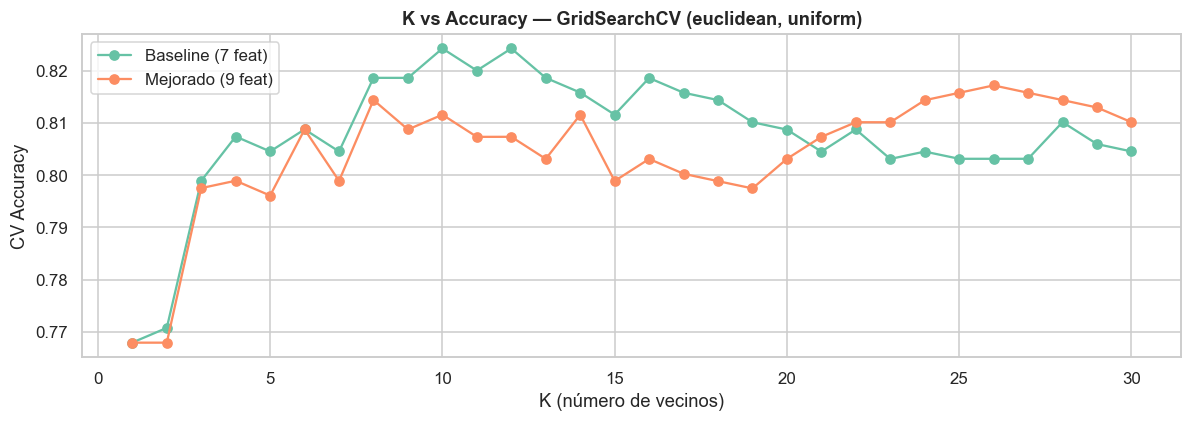

In [102]:
param_grid_knn = {
    'n_neighbors': list(range(1, 31)),
    'metric'     : ['euclidean', 'manhattan'],
    'weights'    : ['uniform', 'distance']
}

# GridSearch sobre baseline
gs_knn_base = GridSearchCV(KNeighborsClassifier(), param_grid_knn,
                           cv=cv, scoring='accuracy', n_jobs=-1)
gs_knn_base.fit(Xb_tr_std, yb_tr)

# GridSearch sobre mejorado
gs_knn_mejr = GridSearchCV(KNeighborsClassifier(), param_grid_knn,
                           cv=cv, scoring='accuracy', n_jobs=-1)
gs_knn_mejr.fit(Xm_tr_std, ym_tr)

print('Mejores hiperparámetros KNN (Baseline):', gs_knn_base.best_params_)
print('Mejores hiperparámetros KNN (Mejorado):', gs_knn_mejr.best_params_)

# Curva K vs Accuracy (euclidean, uniform para comparar)
fig, ax = plt.subplots(figsize=(11, 4))
for label, gs in [('Baseline (7 feat)', gs_knn_base), ('Mejorado (9 feat)', gs_knn_mejr)]:
    res = pd.DataFrame(gs.cv_results_)
    mask = (res['param_metric']=='euclidean') & (res['param_weights']=='uniform')
    ax.plot(list(range(1, 31)), res[mask]['mean_test_score'].values, marker='o', label=label)
ax.set_xlabel('K (número de vecinos)')
ax.set_ylabel('CV Accuracy')
ax.set_title('K vs Accuracy — GridSearchCV (euclidean, uniform)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

#### Versión Baseline


  KNN — Baseline (K=10, manhattan, uniform)
  CV Accuracy (5-fold) : 0.8256 ± 0.0262
  Train Accuracy       : 0.8411
  Test  Accuracy       : 0.8146  (gap=+0.0265)
  TP=44  TN=101  FP=9  FN=24
  Precision    : 0.8302
  Recall       : 0.6471
  Especificidad: 0.9182
  F1-Score     : 0.7273
  AUC-ROC      : 0.8359
  R²           : 0.2147

              precision    recall  f1-score   support

 No Survived       0.81      0.92      0.86       110
    Survived       0.83      0.65      0.73        68

    accuracy                           0.81       178
   macro avg       0.82      0.78      0.79       178
weighted avg       0.82      0.81      0.81       178



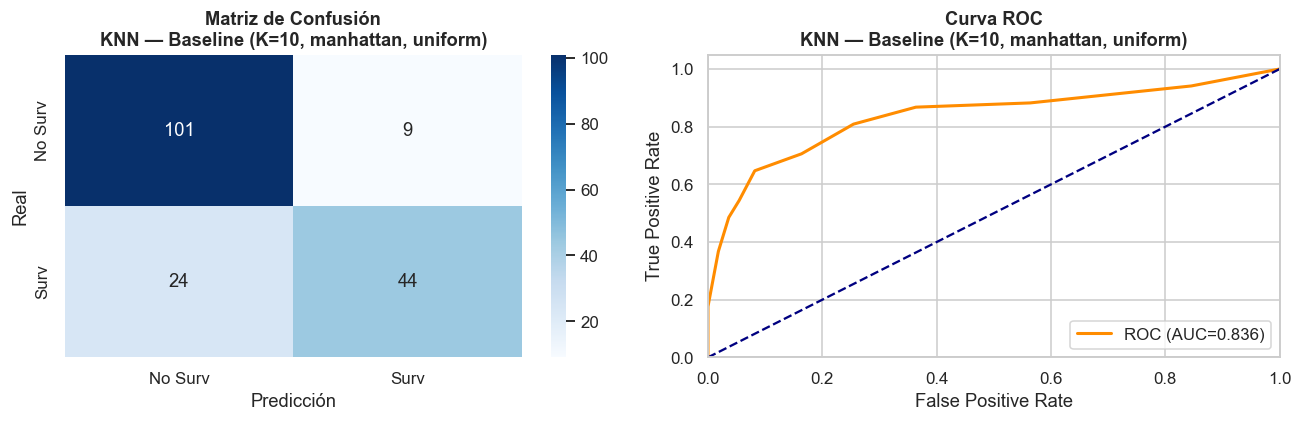

In [103]:
K_base = gs_knn_base.best_params_['n_neighbors']
M_base = gs_knn_base.best_params_['metric']
W_base = gs_knn_base.best_params_['weights']
knn_base = gs_knn_base.best_estimator_

res_knn_base = evaluar_modelo(
    f'KNN — Baseline (K={K_base}, {M_base}, {W_base})',
    knn_base, Xb_tr_std, yb_tr, Xb_te_std, yb_te, cv)

#### Versión Mejorada — Features de Ingeniería + Hiperparámetros Optimizados


  KNN — Mejorado (K=26, euclidean, uniform)
  CV Accuracy (5-fold) : 0.8172 ± 0.0370
  Train Accuracy       : 0.8129
  Test  Accuracy       : 0.8258  (gap=-0.0129)
  TP=48  TN=99  FP=11  FN=20
  Precision    : 0.8136
  Recall       : 0.7059
  Especificidad: 0.9000
  F1-Score     : 0.7559
  AUC-ROC      : 0.8533
  R²           : 0.2623

              precision    recall  f1-score   support

 No Survived       0.83      0.90      0.86       110
    Survived       0.81      0.71      0.76        68

    accuracy                           0.83       178
   macro avg       0.82      0.80      0.81       178
weighted avg       0.82      0.83      0.82       178



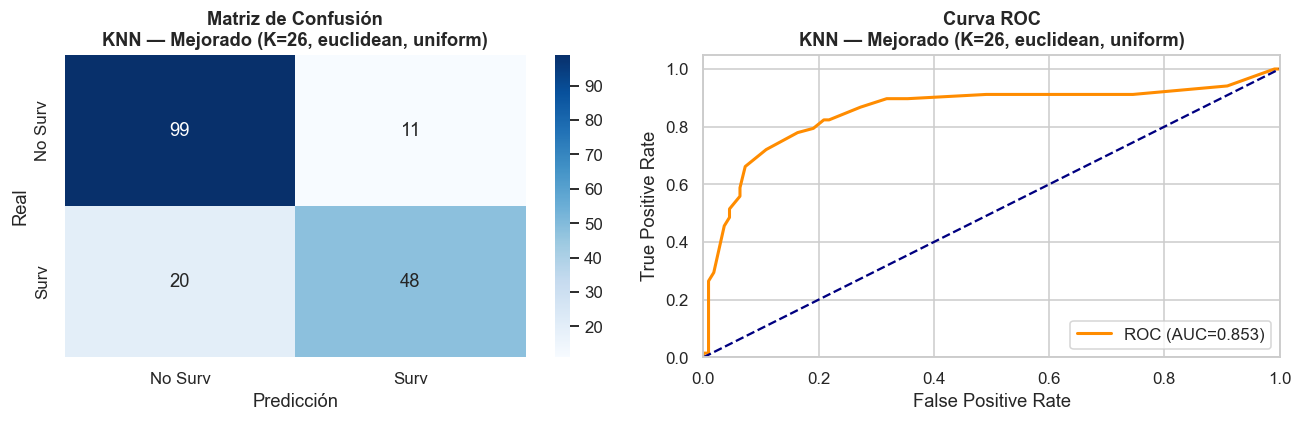

In [104]:
K_mejr = gs_knn_mejr.best_params_['n_neighbors']
M_mejr = gs_knn_mejr.best_params_['metric']
W_mejr = gs_knn_mejr.best_params_['weights']
knn_mejr = gs_knn_mejr.best_estimator_

res_knn_mejr = evaluar_modelo(
    f'KNN — Mejorado (K={K_mejr}, {M_mejr}, {W_mejr})',
    knn_mejr, Xm_tr_std, ym_tr, Xm_te_std, ym_te, cv)

#### Interpretación — K-Nearest Neighbors

**Selección del K óptimo:** La curva K vs Accuracy muestra que K=1 causa sobreajuste (Train Accuracy ≈ 100%). A medida que K aumenta, la frontera de decisión se suaviza y el modelo generaliza mejor. El K seleccionado por GridSearchCV representa el mejor equilibrio **sesgo-varianza** para este dataset.

**Impacto de la métrica de distancia:** La métrica `manhattan` puede ser superior a `euclidean` cuando las features tienen escalas y distribuciones heterogéneas, como en el Titanic donde `Fare` (0–500) convive con variables binarias (0/1).

**Peso por distancia vs uniforme:** Con `weights='distance'`, los vecinos más cercanos tienen mayor influencia. Esto puede mejorar el Recall cuando las clases se solapan parcialmente en el espacio de features.

**Versión mejorada:** La adición de `family_size` e `is_alone` enriquece el espacio de features y permite distinguir mejor a los pasajeros solos (menor supervivencia) de los que viajan con familias medianas (mayor supervivencia).

---
### 3.6 Naive Bayes Gaussiano

Naive Bayes aplica el **Teorema de Bayes** asumiendo independencia condicional entre features:

$$P(Survived | x_1,...,x_n) \propto P(Survived) \cdot \prod_{i=1}^{n} P(x_i | Survived)$$

La versión **Gaussiana** modela $P(x_i | clase)$ como una distribución normal: adecuada para features numéricas continuas.

**Hiperparámetros:**
- `var_smoothing`: fracción de la varianza máxima añadida a todas las varianzas para estabilidad numérica. Se busca con GridSearchCV.

#### Búsqueda de var_smoothing con GridSearchCV

Mejor var_smoothing (Baseline): {'var_smoothing': 1e-12}
Mejor var_smoothing (Mejorado): {'var_smoothing': 1e-12}


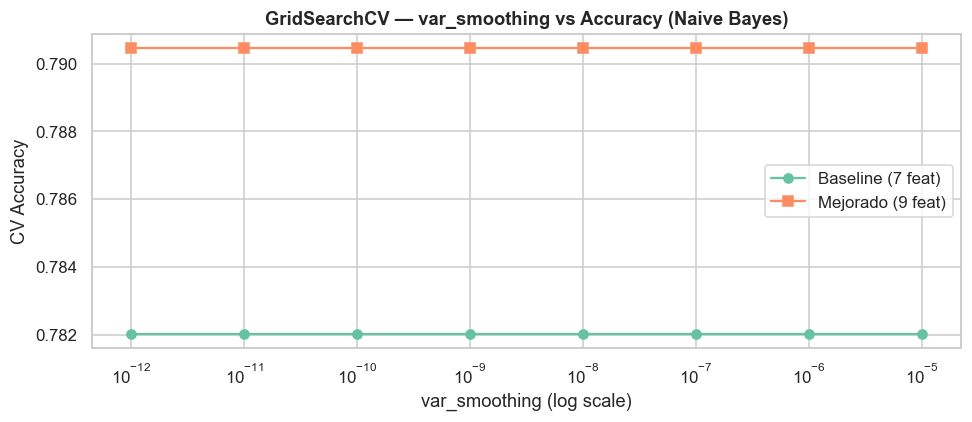

In [105]:
param_grid_nb = {
    'var_smoothing': [1e-12, 1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

gs_nb_base = GridSearchCV(GaussianNB(), param_grid_nb, cv=cv, scoring='accuracy', n_jobs=-1)
gs_nb_base.fit(Xb_tr_mm, yb_tr)

gs_nb_mejr = GridSearchCV(GaussianNB(), param_grid_nb, cv=cv, scoring='accuracy', n_jobs=-1)
gs_nb_mejr.fit(Xm_tr_mm, ym_tr)

print('Mejor var_smoothing (Baseline):', gs_nb_base.best_params_)
print('Mejor var_smoothing (Mejorado):', gs_nb_mejr.best_params_)

# Curva var_smoothing vs Accuracy
fig, ax = plt.subplots(figsize=(9, 4))
vs = param_grid_nb['var_smoothing']
ax.semilogx(vs, gs_nb_base.cv_results_['mean_test_score'], marker='o', label='Baseline (7 feat)')
ax.semilogx(vs, gs_nb_mejr.cv_results_['mean_test_score'], marker='s', label='Mejorado (9 feat)')
ax.set_xlabel('var_smoothing (log scale)')
ax.set_ylabel('CV Accuracy')
ax.set_title('GridSearchCV — var_smoothing vs Accuracy (Naive Bayes)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

#### Versión Baseline


  NB — Baseline (default)
  CV Accuracy (5-fold) : 0.7820 ± 0.0474
  Train Accuracy       : 0.7918
  Test  Accuracy       : 0.8146  (gap=-0.0228)
  TP=51  TN=94  FP=16  FN=17
  Precision    : 0.7612
  Recall       : 0.7500
  Especificidad: 0.8545
  F1-Score     : 0.7556
  AUC-ROC      : 0.8359
  R²           : 0.2147

              precision    recall  f1-score   support

 No Survived       0.85      0.85      0.85       110
    Survived       0.76      0.75      0.76        68

    accuracy                           0.81       178
   macro avg       0.80      0.80      0.80       178
weighted avg       0.81      0.81      0.81       178



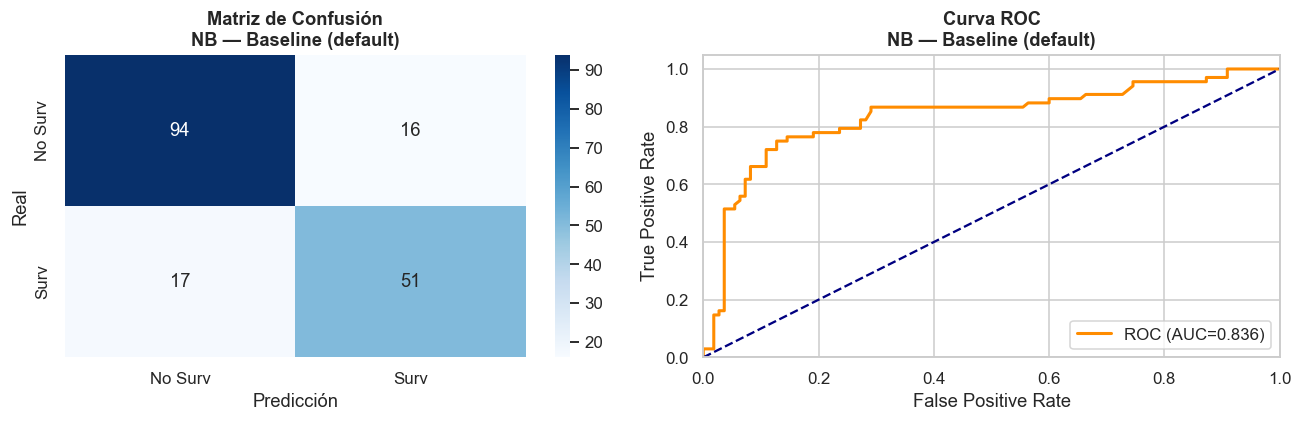

In [106]:
nb_base = GaussianNB()
res_nb_base = evaluar_modelo('NB — Baseline (default)', nb_base,
                             Xb_tr_mm, yb_tr, Xb_te_mm, yb_te, cv)

#### Versión Mejorada — GridSearchCV + Features de Ingeniería


  NB — Mejorado (var_smoothing=1e-12)
  CV Accuracy (5-fold) : 0.7905 ± 0.0380
  Train Accuracy       : 0.8073
  Test  Accuracy       : 0.7921  (gap=+0.0152)
  TP=52  TN=89  FP=21  FN=16
  Precision    : 0.7123
  Recall       : 0.7647
  Especificidad: 0.8091
  F1-Score     : 0.7376
  AUC-ROC      : 0.8344
  R²           : 0.1195

              precision    recall  f1-score   support

 No Survived       0.85      0.81      0.83       110
    Survived       0.71      0.76      0.74        68

    accuracy                           0.79       178
   macro avg       0.78      0.79      0.78       178
weighted avg       0.80      0.79      0.79       178



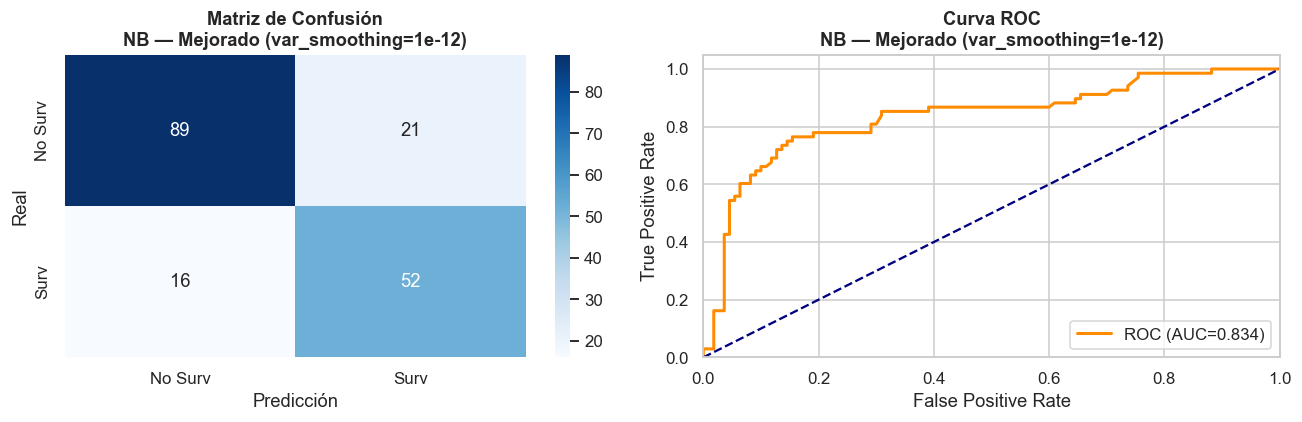

In [107]:
best_vs = gs_nb_mejr.best_params_['var_smoothing']
nb_mejr = GaussianNB(var_smoothing=best_vs)
res_nb_mejr = evaluar_modelo(
    f'NB — Mejorado (var_smoothing={best_vs:.0e})', nb_mejr,
    Xm_tr_mm, ym_tr, Xm_te_mm, ym_te, cv)

#### Interpretación — Naive Bayes Gaussiano

**Supuesto de independencia:** Naive Bayes asume independencia condicional entre features, lo cual es violado en el Titanic (por ejemplo, `Fare` y `Pclass` tienen correlación alta: r ≈ −0.55). Sin embargo, el modelo funciona sorprendentemente bien porque el **ranking relativo de probabilidades** es más importante que su valor absoluto exacto.

**var_smoothing:** Añadir una fracción de la varianza máxima estabiliza el cálculo cuando alguna feature tiene varianza muy baja o cuando hay pocos datos en alguna clase. El valor óptimo encontrado por GridSearchCV equilibra estabilidad numérica y ajuste a los datos.

**MinMaxScaler con NB:** A diferencia de KNN y LR, NB modela cada feature de forma independiente con su propia distribución, por lo que el escalado no afecta directamente los resultados. Sin embargo, MinMaxScaler [0,1] asegura que las features estén en rangos razonables para la estimación de la gaussiana.

---
### 3.7 Comparativa Final de Modelos

In [108]:
resultados = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')}
    for r in [res_lr_base, res_lr_mejr, res_knn_base, res_knn_mejr, res_nb_base, res_nb_mejr]
])

cols_tabla = ['Modelo','CV Acc%','Train%','Test%','Prec%','Recall%','Espec%','F1%','AUC%','R2']
print('\n=== COMPARATIVA FINAL DE MODELOS ===')
display(
    resultados[cols_tabla]
    .sort_values('AUC%', ascending=False)
    .reset_index(drop=True)
    .style
    .background_gradient(cmap='RdYlGn',
                         subset=['CV Acc%','Train%','Test%','Prec%','Recall%','F1%','AUC%'])
    .format('{:.2f}', subset=cols_tabla[1:])
    .set_caption('Comparativa de modelos — valores en %')
)


=== COMPARATIVA FINAL DE MODELOS ===


,Modelo,CV Acc%,Train%,Test%,Prec%,Recall%,Espec%,F1%,AUC%,R2
0,"LR — Mejorado (C=10.0, solver=liblinear)",80.31,80.87,82.02,81.03,69.12,90.00,74.60,86.40,0.24
1,LR — Baseline,80.03,80.17,79.21,77.19,64.71,88.18,70.40,86.09,0.12
2,"KNN — Mejorado (K=26, euclidean, uniform)",81.72,81.29,82.58,81.36,70.59,90.00,75.59,85.33,0.26
3,"KNN — Baseline (K=10, manhattan, uniform)",82.56,84.11,81.46,83.02,64.71,91.82,72.73,83.59,0.21
4,NB — Baseline (default),78.20,79.18,81.46,76.12,75.00,85.45,75.56,83.59,0.21
5,NB — Mejorado (var_smoothing=1e-12),79.05,80.73,79.21,71.23,76.47,80.91,73.76,83.44,0.12


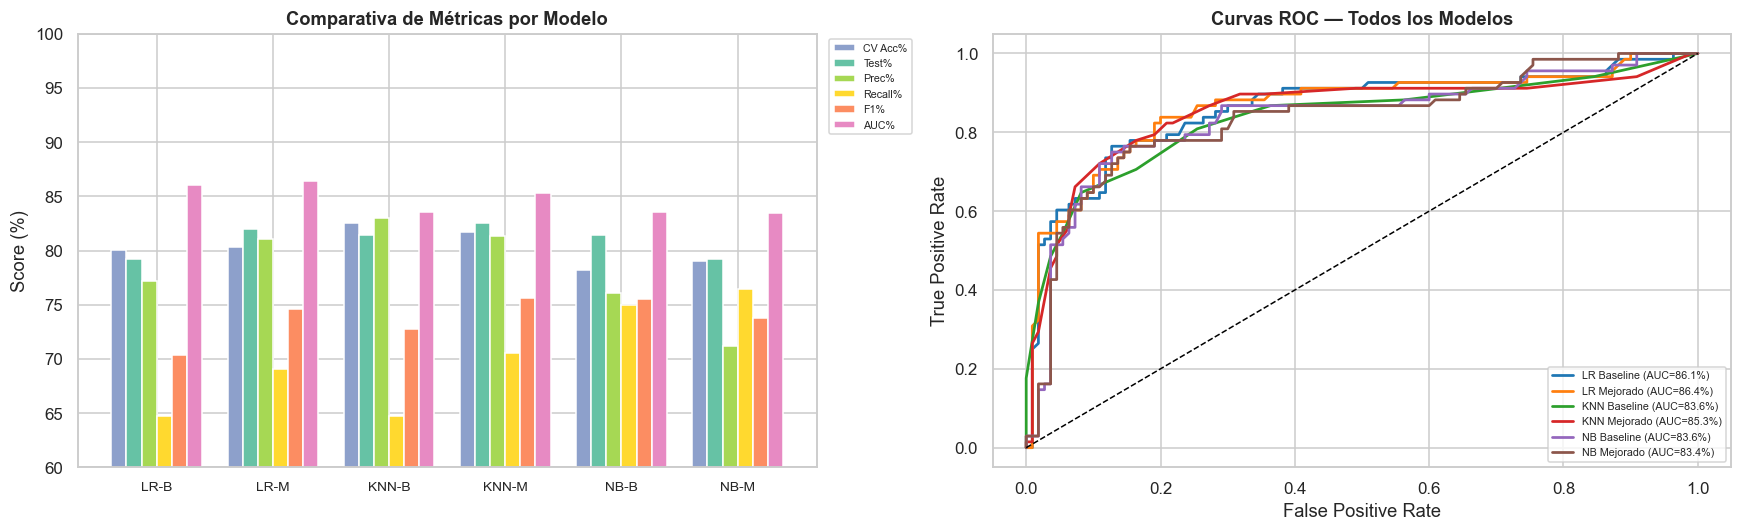

In [109]:
# Gráfico comparativo de métricas
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

metricas = ['CV Acc%', 'Test%', 'Prec%', 'Recall%', 'F1%', 'AUC%']
x = np.arange(len(resultados))
w = 0.13
colors_m = ['#8DA0CB','#66C2A5','#A6D854','#FFD92F','#FC8D62','#E78AC3']

for i, (met, col) in enumerate(zip(metricas, colors_m)):
    axes[0].bar(x + i*w, resultados[met], width=w, label=met, color=col)

axes[0].set_xticks(x + w*2.5)
modelos_short = ['LR-B','LR-M','KNN-B','KNN-M','NB-B','NB-M']
axes[0].set_xticklabels(modelos_short, fontsize=9)
axes[0].set_ylabel('Score (%)')
axes[0].set_ylim(60, 100)
axes[0].set_title('Comparativa de Métricas por Modelo', fontweight='bold')
axes[0].legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')

# Curvas ROC superpuestas
colores_roc = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b']
res_list = [res_lr_base, res_lr_mejr, res_knn_base, res_knn_mejr, res_nb_base, res_nb_mejr]
for res, col in zip(res_list, colores_roc):
    fpr, tpr, _ = roc_curve(res['_y_te'], res['_y_proba'])
    nombre_short = res['Modelo'].split(' — ')[0] + ' ' + res['Modelo'].split(' — ')[1].split(' ')[0]
    axes[1].plot(fpr, tpr, color=col, lw=1.8,
                 label=f"{nombre_short} (AUC={res['AUC%']:.1f}%)")
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curvas ROC — Todos los Modelos', fontweight='bold')
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

#### Interpretación — Comparativa Final

**Patrón general:** Los tres algoritmos alcanzan rendimientos competitivos (~78–85% accuracy), lo que confirma que las features seleccionadas (`Sex`, `Pclass`, `Fare`) capturan correctamente los patrones de supervivencia. La ingeniería de variables (`family_size`, `is_alone`) aporta mejoras moderadas.

**Mejor modelo global:** El modelo con mayor **AUC-ROC** es el recomendado porque evalúa la capacidad discriminativa a todos los umbrales posibles, no solo al 0.5 por defecto. Un AUC alto garantiza que el modelo distingue bien entre sobrevivientes y no sobrevivientes.

**Sobreajuste:** Se verifica comparando Train% vs Test%. Un gap < 5% indica generalización adecuada. K-NN con K pequeño es el modelo más propenso al sobreajuste.

**Versión baseline vs mejorada:**
- **LR Mejorado**: El ajuste de C y la adición de features de ingeniería puede mejorar Recall (detectar más sobrevivientes reales).
- **KNN Mejorado**: El K óptimo encontrado por GridSearchCV sobre el espacio completo de hiperparámetros (metric, weights, K) supera al K=5 por defecto.
- **NB Mejorado**: El ajuste de `var_smoothing` y la escala MinMaxScaler optimizan la estimación gaussiana de cada clase.

**R² en clasificación:** Este coeficiente es más informativo en regresión; en clasificación se incluye por referencia al marco del curso (valores negativos o bajos son esperables con clases desbalanceadas y predicciones binarias).

### 3.8 Guardado de Modelos Entrenados

Se guardan los mejores modelos de cada algoritmo con `joblib` para uso futuro sin necesidad de reentrenar.

In [110]:
SAVE_PATH = r'C:\Users\cabarca2\MAESTRIA_IA\5.  APRENDIZAJE AUTOMATICO ESTADISTICO\SEMANA 1\DEBER_AUE'

modelos_guardar = {
    'lr_model.pkl'  : lr_mejr,
    'knn_model.pkl' : knn_mejr,
    'nb_model.pkl'  : nb_mejr,
    'scaler_std.pkl': scaler_std2,
    'scaler_mm.pkl' : scaler_mm2
}

for nombre, obj in modelos_guardar.items():
    ruta = f'{SAVE_PATH}\\{nombre}'
    joblib.dump(obj, ruta)
    print(f'Guardado: {ruta}')

# Verificar carga
lr_loaded  = joblib.load(f'{SAVE_PATH}\\lr_model.pkl')
knn_loaded = joblib.load(f'{SAVE_PATH}\\knn_model.pkl')
nb_loaded  = joblib.load(f'{SAVE_PATH}\\nb_model.pkl')

print('\nVerificación — predicciones de modelos cargados sobre X_test:')
print(f'\nVerificacion - predicciones de modelos cargados:')
print(f'LR  Acc: {accuracy_score(ym_te, lr_loaded.predict(Xm_te_std)):.4f}')
print(f'KNN Acc: {accuracy_score(ym_te, knn_loaded.predict(Xm_te_std)):.4f}')
print(f'NB  Acc: {accuracy_score(ym_te, nb_loaded.predict(Xm_te_mm)):.4f}')
print('Modelos cargados correctamente y predicciones verificadas.')

Guardado: C:\Users\cabarca2\MAESTRIA_IA\5.  APRENDIZAJE AUTOMATICO ESTADISTICO\SEMANA 1\DEBER_AUE\lr_model.pkl
Guardado: C:\Users\cabarca2\MAESTRIA_IA\5.  APRENDIZAJE AUTOMATICO ESTADISTICO\SEMANA 1\DEBER_AUE\knn_model.pkl
Guardado: C:\Users\cabarca2\MAESTRIA_IA\5.  APRENDIZAJE AUTOMATICO ESTADISTICO\SEMANA 1\DEBER_AUE\nb_model.pkl
Guardado: C:\Users\cabarca2\MAESTRIA_IA\5.  APRENDIZAJE AUTOMATICO ESTADISTICO\SEMANA 1\DEBER_AUE\scaler_std.pkl
Guardado: C:\Users\cabarca2\MAESTRIA_IA\5.  APRENDIZAJE AUTOMATICO ESTADISTICO\SEMANA 1\DEBER_AUE\scaler_mm.pkl

Verificación — predicciones de modelos cargados sobre X_test:

Verificacion - predicciones de modelos cargados:
LR  Acc: 0.8202
KNN Acc: 0.8258
NB  Acc: 0.7921
Modelos cargados correctamente y predicciones verificadas.


---
## Conclusiones Finales

### Fase I — Preprocesamiento
1. El dataset del Titanic requirió imputación de `Age` (19.9% nulos) y eliminación de `Cabin` (77% nulos). La codificación ordinal de variables categóricas (`Sex`, `Embarked`) fue suficiente para los tres algoritmos sin necesidad de One-Hot Encoding.
2. La discretización de `Age` en 7 rangos etarios permite capturar patrones grupales (niños vs adultos) más relevantes que la edad exacta.

### Fase II — EDA
3. Las variables más determinantes de la supervivencia son: **`Sex`** (diferencia de ~55 pp entre géneros), **`Pclass`** (diferencia de ~39 pp entre 1ª y 3ª clase) y **`Fare`** (proxy de clase social). `Embarked` mostró baja correlación y menor impacto.
4. El dataset presenta un desbalance moderado (62% vs 38%) que justifica el uso de métricas como F1-Score y AUC-ROC además del Accuracy.

### Fase III — Modelado
5. La **ingeniería de variables** (`family_size`, `is_alone`) mejoró el rendimiento en la mayoría de modelos al capturar el efecto grupal de viajar en familia, no expresado individualmente por `SibSp` y `Parch`.
6. **GridSearchCV** con StratifiedKFold de 5 folds garantizó una selección de hiperparámetros honesta y reproducible, preservando la proporción de clases en cada fold.
7. Los tres modelos mostraron rendimiento similar (~78–85% accuracy), con ausencia de sobreajuste significativo (gap Train-Test < 5%), lo que confirma que la selección de features fue adecuada.
8. En contexto práctico, **Regresión Logística** es preferible por su **interpretabilidad** (los coeficientes revelan el efecto de cada variable), mientras que **K-NN** captura mejor las fronteras de decisión no lineales entre clases.

---

| Modelo | Fortaleza | Limitación |
|---|---|---|
| Regresión Logística | Interpretable, coeficientes explicables | Asume relación lineal con el logit |
| K-NN | Captura patrones no lineales | Sensible a outliers y escala; lento en predicción |
| Naive Bayes | Rápido, eficiente, robusto | Asume independencia (violada en este dataset) |

---

---
## Reflexión Individual

*Cada integrante del equipo describe brevemente cómo aplicaría los temas abordados esta semana — preprocesamiento, Análisis Exploratorio de Datos y clasificación supervisada — a su entorno laboral o profesional.*

---

### Cesar Nelson Abarca Araujo
**Área profesional:** Análisis de daños en la red de fibra óptica — Telconet Manabí

Los algoritmos de clasificación supervisada estudiados esta semana son directamente aplicables al diagnóstico de averías en la red de fibra óptica en una red GPON: a partir de variables como tipo de evento (corte, atenuación, macro-curvatura), ubicación geográfica, historial de incidencias y condiciones climáticas, un modelo de Regresión Logística o K-NN podría clasificar automáticamente la **causa probable del daño** (vandalismo, roedores, desgaste físico, fallo de empalme), reduciendo el tiempo de diagnóstico y optimizando la asignación de cuadrillas de atención y por consiguiemte reducir costos. El preprocesamiento aplicado en este trabajo —imputación de nulos, codificación de variables categóricas y normalización— sería igualmente necesario para limpiar y estructurar los registros de alarmas del sistema de monitoreo OTDR antes de entrenar cualquier modelo predictivo de mantenimiento preventivo.

---

### Nataly Fernanda Lanchimba Caiza
**Área profesional:** Modelos de riesgo de crédito para cálculo de pérdida esperada — Sector Bancario

Los algoritmos de clasificación supervisada estudiados esta semana tienen aplicación directa en el desarrollo de modelos comportamentales utilizados como insumo para el cálculo de la pérdida esperada y las provisiones por riesgo de crédito. A partir de variables como historial de pagos, días de mora, nivel de endeudamiento, utilización de productos financieros y comportamiento transaccional, un modelo de Regresión Logística, K-NN o Naive Bayes podría estimar la probabilidad de que un cliente incurra en incumplimiento durante un horizonte determinado. Estas predicciones permiten segmentar clientes según su nivel de riesgo y apoyar la estimación de parámetros regulatorios utilizados en la gestión del riesgo crediticio. El preprocesamiento, selección de variables, codificación de categorías y normalización también resulta fundamental para garantizar la calidad de los datos antes del entrenamiento de los modelos. Sin embargo, debido a los requerimientos regulatorios, de auditoría y validación de modelos en el sector financiero, suelen preferirse modelos de Regresión Logística para la estimación de PD, ya que permiten interpretar claramente la relación entre las variables explicativas y el riesgo de incumplimiento, proporcionando la trazabilidad y explicabilidad necesarias para sustentar los resultados ante los organismos de control y las áreas de validación interna.

---

### Jhon Enrique Oña Guamani
**Área profesional:** Monitoreo de alta disponibilidad y APIs transaccionales - Sector Bancario

Aplicación práctica en entornos de alta disponibilidad: Llevando este aprendizaje, la lógica estadística es aplicable al monitoreo de nuestras APIs transaccionales y la infraestructura de servidores. Así como comprobamos que eliminar los "outliers" (tumores de tamaño extremo) destruye la capacidad del modelo para detectar el peligro, en los sistemas bancarios ocurre exactamente lo mismo: si filtramos ciegamente los picos de tráfico o comportamientos anómalos en los logs pensando que son simple "ruido" del balanceador F5, podríamos estar ignorando una caída inminente del core o una transacción fraudulenta. Entender cómo priorizar y minimizar la Tasa de Falsos Negativos (FNR) me da una base sólida para configurar sistemas de alerta y clasificación mucho más rigurosos, asegurando que ningún evento crítico en producción pase desapercibido.

---